<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [2]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, roc_auc_score

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [3]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        if self.w0 is not None:
            self.w = self.w0.copy()
        else:
            self.w = np.zeros(X.shape[1])

        self.loss_history = []

        for i in range(self.max_iter):
            w_old = self.w.copy()
            current_loss = self.calc_loss(X, y)
            self.loss_history.append(current_loss)

            if self.gd_type == 'full':
                gradient = self.calc_gradient(X, y)
                self.w -= self.eta * gradient
            elif self.gd_type == 'stochastic':
                indices = np.random.permutation(X.shape[0])
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                
                for j in range(X_shuffled.shape[0]):
                    X_j = X_shuffled[j:j+1, :] 
                    y_j = y_shuffled[j:j+1]  
                    gradient = self.calc_gradient(X_j, y_j)
                    self.w -= self.eta * gradient
            else:
                raise ValueError(f"Unknown gd_type: {self.gd_type}")
            
            w_diff_norm = np.linalg.norm(self.w - w_old)
            if w_diff_norm < self.tolerance:
                final_loss = self.calc_loss(X, y)
                self.loss_history.append(final_loss)
                break
        
        if i == self.max_iter:
            final_loss = self.calc_loss(X, y)
            self.loss_history.append(final_loss)
            
        return self

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        linear_combination = X @ self.w
        probabilities = self.sigmoid(linear_combination)
        return probabilities


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        probabilities = self.predict_proba(X)
        predictions = (probabilities >= 0.5).astype(int)
        return predictions


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !
        probabilities = self.sigmoid(X @ self.w)
        gradient = X.T @ (probabilities - y) / X.shape[0]
        return gradient


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        probabilities = self.sigmoid(X @ self.w)
        loss = -np.mean(y * np.log(probabilities) + (1 - y) * np.log(1 - probabilities))
        return loss


Теперь проверим работу вашего класса на синтетических данных.

In [4]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [5]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


,gd_type,'full'
,tolerance,0.0001
,max_iter,1000
,w0,None
,eta,0.01


In [6]:
from sklearn.metrics import accuracy_score, roc_auc_score
sklearn_lr = LogisticRegression(
    penalty=None,      
    max_iter=1000,
    tol=1e-4,
    random_state=42,
    solver='lbfgs'     
)
sklearn_lr.fit(X_train, y_train)

models = [
    ("SGD", lr_sgd),
    ("Full GD", lr_full), 
    ("Sklearn", sklearn_lr)
]

for name, model in models:
    y_pred = model.predict(X_test)
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        if y_proba.ndim > 1: 
            y_proba = y_proba[:, 1] if y_proba.shape[1] > 1 else y_proba[:, 0]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    
    print(f"{name:15} | Accuracy: {acc:.4f} | ROC-AUC: {auc}")

SGD             | Accuracy: 0.8647 | ROC-AUC: 0.9379151815761604
Full GD         | Accuracy: 0.8656 | ROC-AUC: 0.9388331416996001
Sklearn         | Accuracy: 0.8681 | ROC-AUC: 0.9398924632108945


В целом, результаты получились довольно близкие. Лучшие значения у Sklearn, это происходит в виду того, что в этой библиотеке алгоритм нахождения оптимума отличен от градиентного спуска. Алгоритм lbfgs обрабатывает данные о вторых производных (матрицы Гессе), за счет чего лучше сходится к оптимуму.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

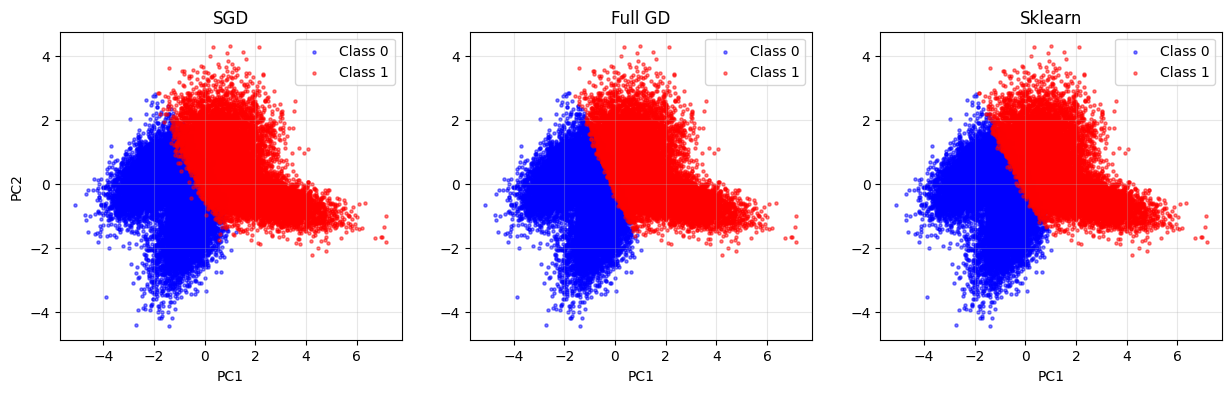

In [7]:
import matplotlib.pyplot as plt

model_names = ['SGD', 'Full GD', 'Sklearn']
models = [lr_sgd, lr_full, sklearn_lr]
predictions = [model.predict(X_test) for model in models]

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, y_pred) in enumerate(zip(model_names, predictions)):
    ax = axes[i]
    ax.scatter(X_test_pca[y_pred == 0, 0], X_test_pca[y_pred == 0, 1], 
               alpha=0.5, label='Class 0', c='blue', s=5)
    ax.scatter(X_test_pca[y_pred == 1, 0], X_test_pca[y_pred == 1, 1], 
               alpha=0.5, label='Class 1', c='red', s=5)
    ax.set_title(f'{name}')
    ax.set_xlabel(f'PC1')
    if i == 0:
        ax.set_ylabel(f'PC2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.show()

Модели выглядят очено схоже. Различия визуально наблюдаются на границе классов. Визуально в Full GD гриница очерчена лучшим образом

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [8]:
from sklearn.model_selection import train_test_split

PATH = './train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [9]:
# Ваш код здесь
print(data.isna().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [11]:
data['keyword'] = data['keyword'].fillna('')
data['location'] = data['location'].fillna('')
print(data.isna().sum())

id          0
keyword     0
location    0
text        0
target      0
dtype: int64


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [12]:
# Ваш код здесь, не забудьте выводы
for col in ['keyword', 'location', 'target']:
    unique = data[col].nunique()
    total = len(data[col])
    print(f"{col}:{unique} из {total} ({unique/total:%})")

keyword:222 из 7613 (2.916065%)
location:3342 из 7613 (43.898595%)
target:2 из 7613 (0.026271%)


По target видно, что это бинарная классификация. Keyword обладает крайне низкой уникальностью.

- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [13]:
# Ваш код здесь
class_ratios = data['target'].value_counts(normalize=True)

print(f"класс 0: ({class_ratios[0]})")
print(f"класс 1: ({class_ratios[1]})")

класс 0: (0.5703402075397347)
класс 1: (0.4296597924602653)


Хоть и дисбаланс умеренный, буду использовать ROC-AUC, а не accuracy, так как ROC-AUC даёт вероятностных результат.

- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [14]:
# Ваш код здесь
data['text_combined'] = data['keyword'] + ' ' + data['location'] + ' ' + data['text']

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [15]:
X = data['text_combined']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [16]:
# Ваш код здесь
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [17]:
print(X_train_vect.shape)
print(X_test_vect.shape)

(5329, 18455)
(2284, 18455)


- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [18]:
# Ваш код здесь
from sklearn.metrics import roc_auc_score
sklearn_lr.fit(X_train_vect, y_train)
y_pred = sklearn_lr.predict(X_test_vect)
y_pred_proba = sklearn_lr.predict_proba(X_test_vect)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"roc-auc: {roc_auc}")

roc-auc: 0.8301829737634976


Значение ROC-AUC 0.83 говорит о хорошем результате. Результат хуже, чем на синтетических данных, но текстовые данные гораздо сложнее.

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [19]:
# Ваш код здесь
from sklearn.svm import SVC
import time
start_time = time.time()
svc = SVC(random_state=42, probability=True)
svc.fit(X_train_vect, y_train)
train_time = time.time() - start_time
print(f"время обучения: {train_time} секунд")

start_time = time.time()
y_pred_svc = svc.predict(X_test_vect)
y_pred_proba_svc = svc.predict_proba(X_test_vect)[:, 1]
predict_time = time.time() - start_time

roc_auc_svc = roc_auc_score(y_test, y_pred_proba_svc)
print(f"roc-auc:  {roc_auc_svc}")
print(f"время предсказания: {predict_time} сек")


время обучения: 11.598520278930664 секунд
roc-auc:  0.8556729249725885
время предсказания: 1.6695806980133057 сек


Качество модели получилось лучшее, но время обучения и предсказывания очень большое.

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [20]:
# Ваш код здесь
print(X_train.shape)
n_samples = len(X_train)
max_samples = n_samples // 4
print(f'количество признаков необходимо = {max_samples}')

params = {'max_features': 1332, 'min_df': 5}

vectorizer = CountVectorizer(**params)
X_train_new = vectorizer.fit_transform(X_train)
X_test_new = vectorizer.transform(X_test)

logreg = LogisticRegression(max_iter=1000).fit(X_train_new, y_train)
svc = SVC(probability=True, random_state=42).fit(X_train_new, y_train)

lr_score = roc_auc_score(y_test, logreg.predict_proba(X_test_new)[:, 1])
svc_score = roc_auc_score(y_test, svc.predict_proba(X_test_new)[:, 1])

print(f"\nLogReg ROC-AUC: {lr_score} (изменение: {lr_score-0.8302})")
print(f"SVC ROC-AUC:    {svc_score} (изменение: {svc_score-0.8267})")

(5329,)
количество признаков необходимо = 1332

LogReg ROC-AUC: 0.8457195638036173 (изменение: 0.015519563803617298)
SVC ROC-AUC:    0.8522857582697919 (изменение: 0.025585758269791925)


Задал ограничение на max_features, то есть на количество самых часто встречаемых слов из всех = 1332. При этом задал значение min_df=5, что означает, что слова, встречающиеся с частотой менее пяти будут игнорироваться, таким образом, убрал рекие слова, которые могли включать в себя шумы.

### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [21]:
# Ваш код здесь
from scipy.sparse import hstack

X_cat = data[['keyword', 'location', 'text']].copy().fillna('')
y = data['target']
X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.3, random_state=42, stratify=y)

vectorizer_keyword = CountVectorizer(max_features=500)
vectorizer_location = CountVectorizer(max_features=500) 
vectorizer_text = CountVectorizer()

X_keyword_train = vectorizer_keyword.fit_transform(X_train_cat['keyword'])
X_location_train = vectorizer_location.fit_transform(X_train_cat['location'])
X_text_train = vectorizer_text.fit_transform(X_train_cat['text'])

X_keyword_test = vectorizer_keyword.transform(X_test_cat['keyword'])
X_location_test = vectorizer_location.transform(X_test_cat['location'])
X_text_test = vectorizer_text.transform(X_test_cat['text'])

# объединение векторизованных столбцов
X_train_combined = hstack([X_keyword_train, X_location_train, X_text_train])
X_test_combined = hstack([X_keyword_test, X_location_test, X_text_test])

logreg = LogisticRegression(max_iter=1000).fit(X_train_combined, y_train)
svc = SVC(probability=True).fit(X_train_combined, y_train)

lr_score = roc_auc_score(y_test, logreg.predict_proba(X_test_combined)[:, 1])
svc_score = roc_auc_score(y_test, svc.predict_proba(X_test_combined)[:, 1])

print(f"LogReg: {lr_score} (difference: {lr_score-0.8302})")
print(f"SVC: {svc_score} (difference: {svc_score-0.8267})")


LogReg: 0.8544764180206736 (difference: 0.024276418020673596)
SVC: 0.8597641450021631 (difference: 0.03306414500216315)


Такой подход дал прибавку в качестве для LogReg и SVC в несколько сотых.

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [24]:
# Ваш код здесь
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
param_grid = {
    "C": [0.1, 1, 10],
    'penalty': ['l2'], 
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced'] 
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000, 
        random_state=42,
        n_jobs=-1 
    ),
    param_grid,
    cv=3,  
    scoring='roc_auc',
    n_jobs=-1 
)

grid.fit(X_train_vect, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший ROC-AUC: {grid.best_score_}")

y_pred_proba = grid.predict_proba(X_test_vect)[:, 1]
roc_test = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC на тесте: {roc_test:.4f}")
print(f"Разница с baseline (0.8302): {roc_test - 0.8302}")

Лучшие параметры: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Лучший ROC-AUC: 0.4866731997977604
ROC-AUC на тесте: 0.4943
Разница с baseline (0.8302): -0.33589570887538606


- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [25]:
# Ваш код здесь
param_grid_svc = {
    'C': [0.1, 1, 10],  
    'kernel': ['linear'],  
    'class_weight': ['balanced'], 
    'gamma': ['scale']  
}

svc_model = SVC(
    probability=True, 
    random_state=42,
    max_iter=2000, 
    cache_size=1000 
)

grid_svc = GridSearchCV(
    svc_model,
    param_grid_svc,
    cv=3, 
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1 
)

grid_svc.fit(X_train_vect, y_train)

print(f"лучшие параметры SVC: {grid_svc.best_params_}")
print(f"лучший ROC-AUC SVC: {grid_svc.best_score_}")

y_pred_proba_svc = grid_svc.predict_proba(X_test_vect)[:, 1]
roc_test_svc = roc_auc_score(y_test, y_pred_proba_svc)
print(f"ROC-AUC SVC на тесте: {roc_test_svc}")
print(f"разница с baseline SVC (0.8267): {roc_test_svc - 0.8267}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
лучшие параметры SVC: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
лучший ROC-AUC SVC: 0.49118852662184254
ROC-AUC SVC на тесте: 0.49513590138964186
разница с baseline SVC (0.8267): -0.3315640986103581


Выводы следующие: подбор гиперпараметров не получается, модель ломается. ROC-AUC со значением 0.5 свидетельствует о том, что модель "угадывает" классы.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()), 
    ('lr', LogisticRegression())  
])

lr_pipeline.fit(X_train, y_train) 
y_pred_lr = lr_pipeline.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()), 
    ('svc', SVC(probability=True)) 
])

svc_pipeline.fit(X_train, y_train) 
y_pred_svc = svc_pipeline.predict_proba(X_test)[:, 1]